# Wrangling

In [2]:
require(tidyverse)

In [3]:
nhanes <- read_csv("data/nhanes.csv")

Rows: 20293 Columns: 78
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (29): SurveyYr, Gender, Race1, Race3, Education, MaritalStatus, HHIncome...
dbl (49): ID, Age, AgeMonths, HHIncomeMid, Poverty, HomeRooms, Weight, Lengt...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [63]:
#Other imports
require(readxl) #for reading Excel files and read_excel()
require(arrow) # read_parquet()

In [4]:
nhanes |> select(ID, Age, Gender, Race=Race1, Education, Weight, Height) -> nhanes.mini

In [5]:
nhanes.mini

# A tibble: 20,293 × 7
      ID   Age Gender Race     Education      Weight Height
   <dbl> <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl>
 1 51624    34 male   White    High School      87.4   165.
 2 51625     4 male   Other    NA               17     105.
 3 51626    16 male   Black    NA               72.3   181.
 4 51627    10 male   Black    NA               39.8   148.
 5 51628    60 female Black    High School     117.    166 
 6 51629    26 male   Mexican  9 - 11th Grade   97.6   173 
 7 51630    49 female White    Some College     86.7   168.
 8 51631     1 female White    NA                9.4    NA 
 9 51632    10 male   Hispanic NA               26     140.
10 51633    80 male   White    Some College     79.1   174.
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [6]:
nhanes.mini |> mutate(data_source = 'NHANES')

# A tibble: 20,293 × 8
      ID   Age Gender Race     Education      Weight Height data_source
   <dbl> <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl> <chr>      
 1 51624    34 male   White    High School      87.4   165. NHANES     
 2 51625     4 male   Other    NA               17     105. NHANES     
 3 51626    16 male   Black    NA               72.3   181. NHANES     
 4 51627    10 male   Black    NA               39.8   148. NHANES     
 5 51628    60 female Black    High School     117.    166  NHANES     
 6 51629    26 male   Mexican  9 - 11th Grade   97.6   173  NHANES     
 7 51630    49 female White    Some College     86.7   168. NHANES     
 8 51631     1 female White    NA                9.4    NA  NHANES     
 9 51632    10 male   Hispanic NA               26     140. NHANES     
10 51633    80 male   White    Some College     79.1   174. NHANES     
# ℹ 20,283 more rows
# ℹ Use `print(n = ...)` to see more rows

In [18]:
nhanes.mini |> 
  mutate(BMI = (Weight/(Height/100)^2)) |> 
  mutate(Age_Group = ifelse(Age < 18, "Child", "Adult")) |> 
  mutate(Age_Category = case_when(
    Age < 18 ~ "Child", 
    Age |> between(18, 40) ~ "Young Adult", 
    Age |> between(41, 65) ~ "Middle-aged",
    Age > 65 ~ "Elderly",
    .default = NA
  ))

# A tibble: 20,293 × 10
      ID   Age Gender Race  Education Weight Height   BMI Age_Group Age_Category
   <dbl> <dbl> <chr>  <chr> <chr>      <dbl>  <dbl> <dbl> <chr>     <chr>       
 1 51624    34 male   White High Sch…   87.4   165.  32.2 Adult     Young Adult 
 2 51625     4 male   Other NA          17     105.  15.3 Child     Child       
 3 51626    16 male   Black NA          72.3   181.  22.0 Child     Child       
 4 51627    10 male   Black NA          39.8   148.  18.2 Child     Child       
 5 51628    60 female Black High Sch…  117.    166   42.4 Adult     Middle-aged 
 6 51629    26 male   Mexi… 9 - 11th…   97.6   173   32.6 Adult     Young Adult 
 7 51630    49 female White Some Col…   86.7   168.  30.6 Adult     Middle-aged 
 8 51631     1 female White NA           9.4    NA   NA   Child     Child       
 9 51632    10 male   Hisp… NA          26     140.  13.2 Child     Child       
10 51633    80 male   White Some Col…   79.1   174.  26.0 Adult     Elderly     
# ℹ 

In [25]:
nhanes.mini |> mutate(Demographic = paste0(Age, 'yr old ', Race, ' ',  Gender))

# A tibble: 20,293 × 8
      ID   Age Gender Race     Education      Weight Height Demographic         
   <dbl> <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl> <chr>               
 1 51624    34 male   White    High School      87.4   165. 34yr old White male 
 2 51625     4 male   Other    NA               17     105. 4yr old Other male  
 3 51626    16 male   Black    NA               72.3   181. 16yr old Black male 
 4 51627    10 male   Black    NA               39.8   148. 10yr old Black male 
 5 51628    60 female Black    High School     117.    166  60yr old Black fema…
 6 51629    26 male   Mexican  9 - 11th Grade   97.6   173  26yr old Mexican ma…
 7 51630    49 female White    Some College     86.7   168. 49yr old White fema…
 8 51631     1 female White    NA                9.4    NA  1yr old White female
 9 51632    10 male   Hispanic NA               26     140. 10yr old Hispanic m…
10 51633    80 male   White    Some College     79.1   174. 80yr old White male 
# ℹ 2

In [26]:
nhanes.mini |> mutate(Demographic = paste(Age, 'yr old', Race, Gender))

# A tibble: 20,293 × 8
      ID   Age Gender Race     Education      Weight Height Demographic         
   <dbl> <dbl> <chr>  <chr>    <chr>           <dbl>  <dbl> <chr>               
 1 51624    34 male   White    High School      87.4   165. 34 yr old White male
 2 51625     4 male   Other    NA               17     105. 4 yr old Other male 
 3 51626    16 male   Black    NA               72.3   181. 16 yr old Black male
 4 51627    10 male   Black    NA               39.8   148. 10 yr old Black male
 5 51628    60 female Black    High School     117.    166  60 yr old Black fem…
 6 51629    26 male   Mexican  9 - 11th Grade   97.6   173  26 yr old Mexican m…
 7 51630    49 female White    Some College     86.7   168. 49 yr old White fem…
 8 51631     1 female White    NA                9.4    NA  1 yr old White fema…
 9 51632    10 male   Hispanic NA               26     140. 10 yr old Hispanic …
10 51633    80 male   White    Some College     79.1   174. 80 yr old White male
# ℹ 2

### Forcats

In [28]:
class(nhanes$Education)

[1] "character"

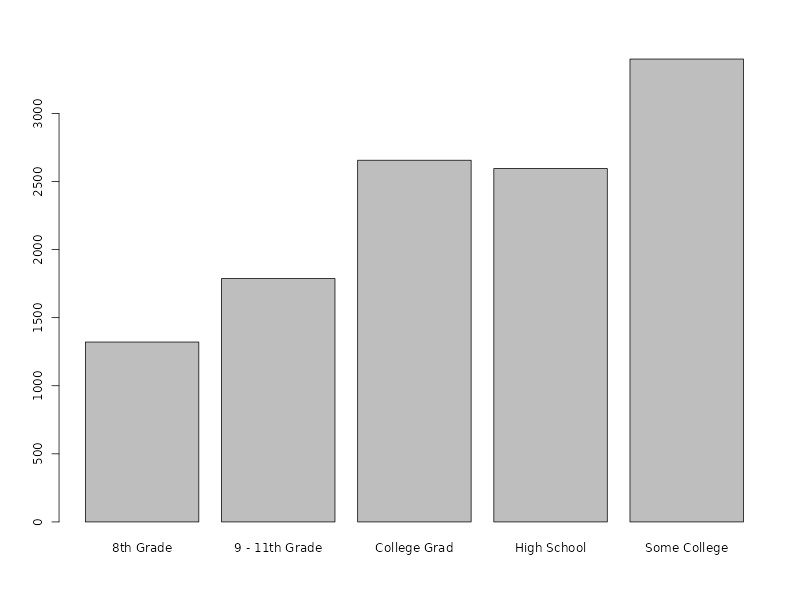

In [36]:
nhanes$Education |> table() |> barplot()

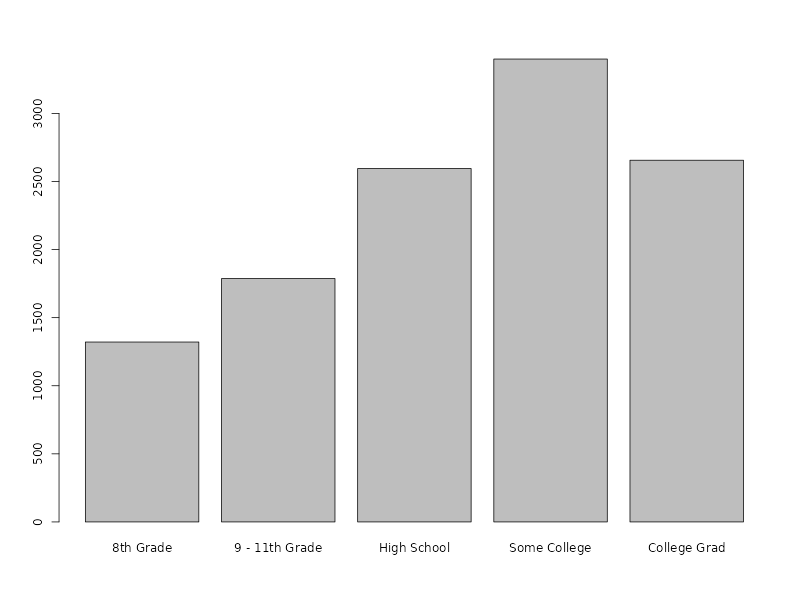

In [37]:
nhanes$Education |> fct_relevel(
  "8th Grade", 
  "9 - 11th Grade", 
  "High School", 
  "Some College", 
  "College Grad"
) |> table() |> barplot()

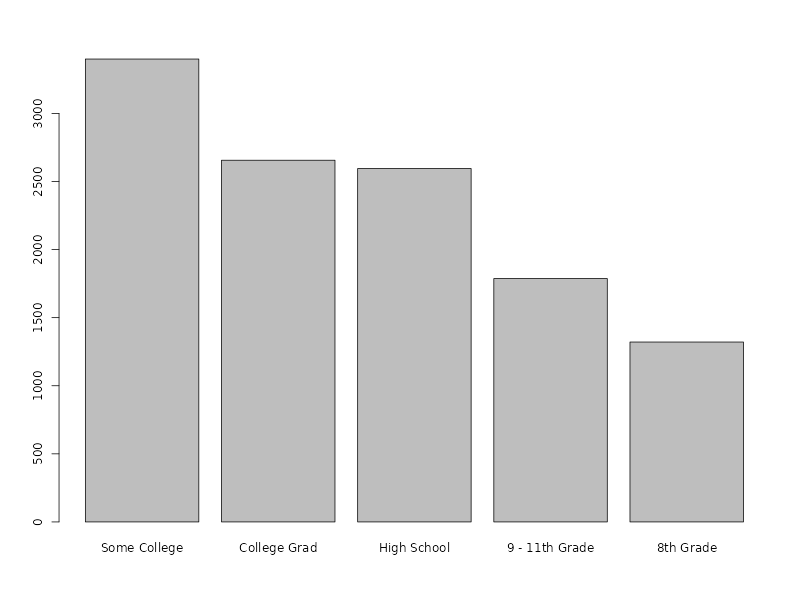

In [ ]:
nhanes$Education |> fct_infreq()  |> table() |> barplot()

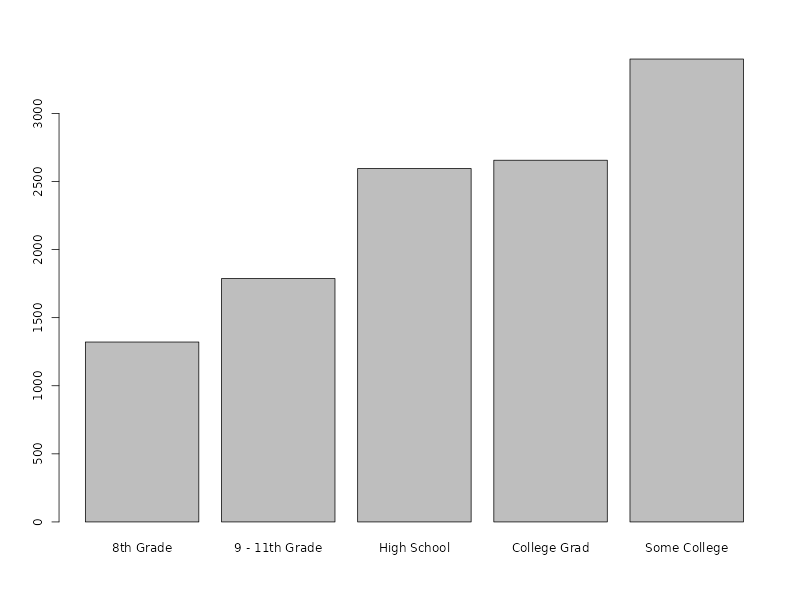

In [43]:
nhanes$Education |> fct_infreq() |> fct_rev()  |> table() |> barplot()

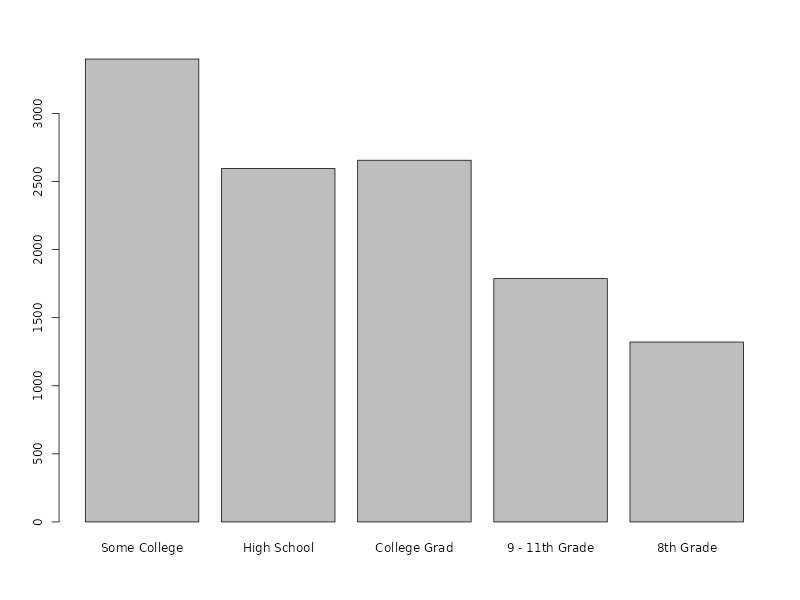

In [42]:
nhanes$Education |> fct_rev() |> table() |>  barplot()

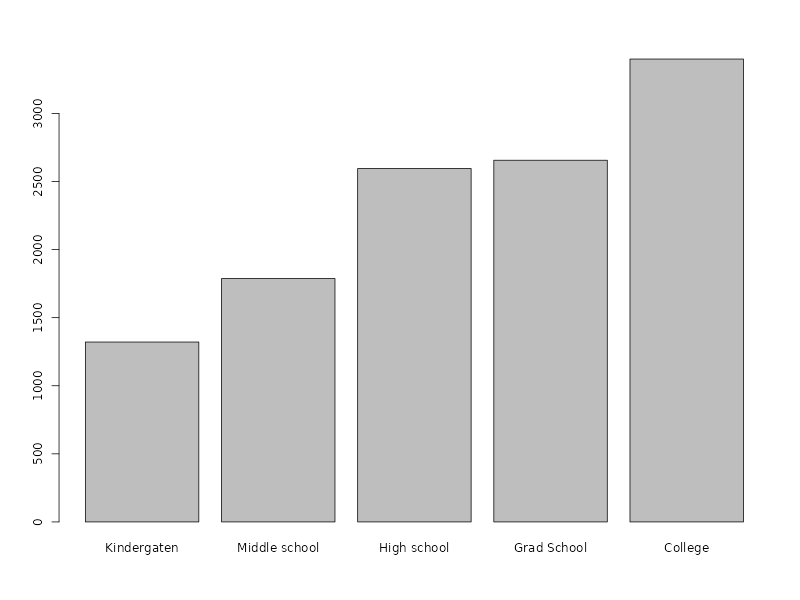

In [54]:
nhanes$Education |> fct_recode(
  "Kindergaten"="8th Grade", 
  "Middle school"="9 - 11th Grade", 
  "High school"="High School", 
  "College"="Some College", 
  "Grad School"="College Grad"
) |> fct_relevel(
    "Kindergaten", 
  "Middle school", 
  "High school", 
  "College", 
  "Grad School"
) |> fct_infreq() |> fct_rev() |> table() |> barplot()

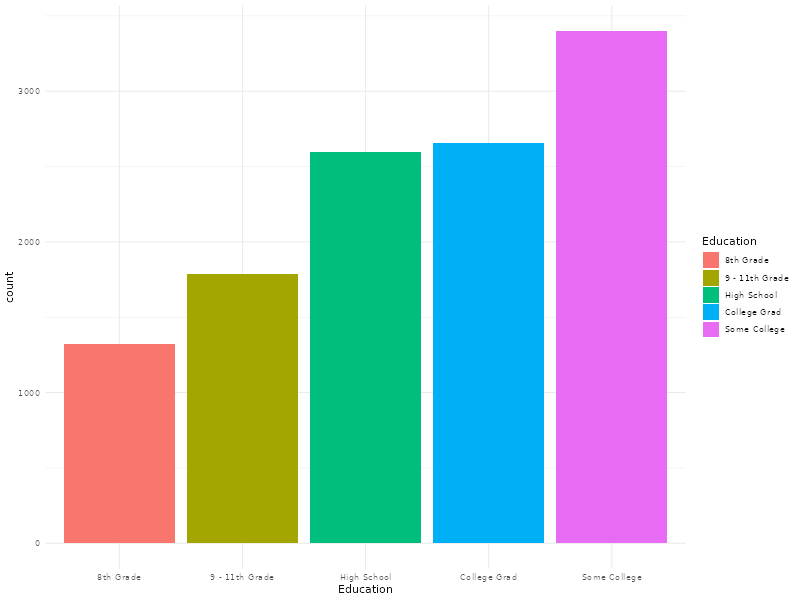

In [60]:
nhanes |> 
  filter(!is.na(Education)) |> 
  mutate(Education = Education |> fct_infreq() |> fct_rev() ) |>
  ggplot() + aes(Education, fill=Education) + geom_bar() + theme_minimal()

### Lubridate

In [65]:
store <- read_excel("data/SuperStore.xlsx")

In [66]:
store

# A tibble: 4,117 × 10
   `Order ID`   `Order Date`        `Customer Name` City  Country Region Segment
   <chr>        <dttm>              <chr>           <chr> <chr>   <chr>  <chr>  
 1 BN-2011-740… 2011-01-01 00:00:00 Ruby Patel      Stoc… Sweden  North  Home O…
 2 AZ-2011-905… 2011-01-03 00:00:00 Summer Hayward  Sout… United… North  Consum…
 3 AZ-2011-667… 2011-01-04 00:00:00 Devin Huddlest… Vale… France  Centr… Consum…
 4 BN-2011-281… 2011-01-04 00:00:00 Mary Parker     Birm… United… North  Corpor…
 5 AZ-2011-617… 2011-01-05 00:00:00 Daniel Burke    Echi… France  Centr… Home O…
 6 AZ-2011-291… 2011-01-07 00:00:00 Fredrick Bever… La S… France  Centr… Corpor…
 7 BN-2011-324… 2011-01-08 00:00:00 Archer Hort     Toul… France  Centr… Consum…
 8 AZ-2011-671… 2011-01-11 00:00:00 Evie Flockhart  Genoa Italy   South  Consum…
 9 AZ-2011-482… 2011-01-11 00:00:00 Faith Greenwood Vien… Austria Centr… Consum…
10 AZ-2011-643… 2011-01-11 00:00:00 Summer Hayward  Murc… Spain   South  Consum…
# ℹ 4

In [67]:
"Dec 20 1987"
"12-20-87"
"87/12/20"

[1] "87/12/20"

In [68]:
mdy("Dec 20 1987")

[1] "1987-12-20"

In [69]:
mdy("12-20-87")

[1] "1987-12-20"

In [70]:
ymd("87/12/20")

[1] "1987-12-20"

In [74]:
Sys.Date()

[1] "2026-04-18"

In [82]:
floor(as.numeric(Sys.Date() - ymd("87/12/20"))/365)

[1] 38

In [93]:
ymd("87/12/20") + years(10)

[1] "1997-12-20"

In [100]:
store |> 
  select(`Order ID`, `Order Date`, `Customer Name`) |> 
  mutate(`Order Date` = ymd(`Order Date`)) |> 
  mutate(Since = paste0(floor(as.numeric(Sys.Date() - `Order Date`)/365.25), " years")) 

# A tibble: 4,117 × 4
   `Order ID`      `Order Date` `Customer Name`    Since   
   <chr>           <date>       <chr>              <chr>   
 1 BN-2011-7407039 2011-01-01   Ruby Patel         15 years
 2 AZ-2011-9050313 2011-01-03   Summer Hayward     15 years
 3 AZ-2011-6674300 2011-01-04   Devin Huddleston   15 years
 4 BN-2011-2819714 2011-01-04   Mary Parker        15 years
 5 AZ-2011-617423  2011-01-05   Daniel Burke       15 years
 6 AZ-2011-2918397 2011-01-07   Fredrick Beveridge 15 years
 7 BN-2011-3248724 2011-01-08   Archer Hort        15 years
 8 AZ-2011-6712797 2011-01-11   Evie Flockhart     15 years
 9 AZ-2011-4827146 2011-01-11   Faith Greenwood    15 years
10 AZ-2011-6439906 2011-01-11   Summer Hayward     15 years
# ℹ 4,107 more rows
# ℹ Use `print(n = ...)` to see more rows

In [103]:
store |> distinct()

# A tibble: 4,117 × 10
   `Order ID`   `Order Date`        `Customer Name` City  Country Region Segment
   <chr>        <dttm>              <chr>           <chr> <chr>   <chr>  <chr>  
 1 BN-2011-740… 2011-01-01 00:00:00 Ruby Patel      Stoc… Sweden  North  Home O…
 2 AZ-2011-905… 2011-01-03 00:00:00 Summer Hayward  Sout… United… North  Consum…
 3 AZ-2011-667… 2011-01-04 00:00:00 Devin Huddlest… Vale… France  Centr… Consum…
 4 BN-2011-281… 2011-01-04 00:00:00 Mary Parker     Birm… United… North  Corpor…
 5 AZ-2011-617… 2011-01-05 00:00:00 Daniel Burke    Echi… France  Centr… Home O…
 6 AZ-2011-291… 2011-01-07 00:00:00 Fredrick Bever… La S… France  Centr… Corpor…
 7 BN-2011-324… 2011-01-08 00:00:00 Archer Hort     Toul… France  Centr… Consum…
 8 AZ-2011-671… 2011-01-11 00:00:00 Evie Flockhart  Genoa Italy   South  Consum…
 9 AZ-2011-482… 2011-01-11 00:00:00 Faith Greenwood Vien… Austria Centr… Consum…
10 AZ-2011-643… 2011-01-11 00:00:00 Summer Hayward  Murc… Spain   South  Consum…
# ℹ 4

In [ ]:
#Unions
#Joins
#Window Functions

In [ ]:
left_join()
cross_join()
inner_join()
union()
union_all()
first()
last()
lead()
lag()
rank()
dense_rank()
row_number()